In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
analysis_directory = TemporaryDirectory()
repacked_counts = str(Path(analysis_directory.name) / "counts.zarr")
repack_store(f"{dataset}/data.zarr", repacked_counts, nthreads=2)
ds = scarf.mount_datastore(
    repacked_counts,
    at=str(Path(analysis_directory.name) / "annotation_analysis.zarr"),
    default_assay="RNA",
    nthreads=4,
)

run = ds.pipeline.run(
    filtering=False,
    cell_cycle=False,
    doublets=False,
)
cluster_ref = run["clusters"]
marker_ref = run["markers"]
cluster_values = np.asarray(run.cells.fetch("clusters"))
pd.Series(cluster_values).value_counts().sort_index()

Downloading bucket files: 48357614 / 48357614 complete

Downloading bytes: 48357614 / 48357614 complete

Repacking RNA/artifacts/reduction//loadings: 1 / 1 complete

Repacking RNA/artifacts/reduction//data: 1 / 1 complete

Repacking RNA/artifacts/dendrogram//data: 1 / 1 complete

...

Identifying neighbors: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Training UMAP: 300 / 300 complete

Finding markers: 2 / 2 complete

1      699
2       24
3      249
4     1257
5      515
6      316
7      464
8      139
9      250
10      15
11      12
Name: count, dtype: int64

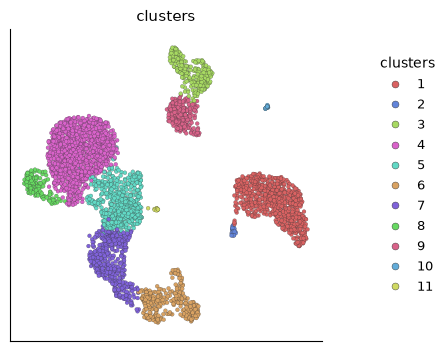

In [2]:
ds.plots.embedding(run=run, layout="umap", color_by="clusters")

In [3]:
group_id = pd.Series(cluster_values).value_counts().index[0]
group_markers = ds.get_markers(
    marker=marker_ref,
    group_id=group_id,
    min_score=-1,
    min_frac_exp=-1,
)
group_markers[
    [
        "feature_name",
        "score",
        "frac_exp",
        "fold_change",
        "auc",
        "p_value",
        "p_value_adjusted",
    ]
].head(10)

,feature_name,score,frac_exp,fold_change,auc,p_value,p_value_adjusted
0,ADTRP,0.62103,0.23469,14.03478,0.60657,1.601551e-103,2.582346e-101
1,ANKRD55,0.54764,0.14956,19.82392,0.57053,1.221953e-74,1.095771e-72
2,TSHZ2,0.54607,0.32936,7.20419,0.64192,2.782494e-127,6.099299e-125
3,CHRM3-AS2,0.49412,0.38504,8.29466,0.66724,7.529017e-154,2.254537e-151
4,TCEA3,0.47976,0.20843,7.39656,0.58862,1.947649e-73,1.723490e-71
5,AC005842.1,0.47578,0.15831,8.66719,0.56938,2.819052e-61,1.861130e-59
6,FHIT,0.47028,0.61734,10.42009,0.77557,2.138684e-285,2.241475e-282
7,EPHX2,0.45244,0.39061,7.50544,0.66540,4.136515e-143,1.083831e-140
8,CMTM8,0.43936,0.29833,4.80677,0.61574,2.436382e-81,2.545525e-79
9,MAN1C1,0.43103,0.32060,5.42255,0.62639,8.298346e-91,1.082918e-88


In [4]:
markers = ds.get_markers(
    marker=marker_ref,
    group_id=None,
    min_score=-1,
    min_frac_exp=-1,
)
panel_hits = (
    markers[markers["feature_name"].astype(str).isin(["CD14", "MS4A1", "CD3D"])]
    .sort_values(["feature_name", "score"], ascending=[True, False])
    .groupby("feature_name", as_index=False)
    .head(1)[["feature_name", "group_id", "score", "auc", "frac_exp"]]
)
panel_hits

,feature_name,group_id,score,auc,frac_exp
2,CD14,1,0.91242,0.98348,0.96853
268371,CD3D,7,0.26705,0.77388,0.98060
134168,MS4A1,3,0.48628,0.96415,0.99598


In [5]:
unique = sorted(pd.unique(cluster_values), key=str)
label_map = {value: f"Cluster {value}" for value in unique}
for gene, name in (
    ("CD14", "Monocytes"),
    ("MS4A1", "B cells"),
    ("CD3D", "T cells"),
):
    hit = panel_hits.loc[panel_hits["feature_name"].astype(str) == gene]
    if not hit.empty:
        label_map[hit.iloc[0]["group_id"]] = name

cell_type = np.asarray([label_map[value] for value in cluster_values], dtype=object)
ds.cells.insert("cell_type", cell_type, key="I", overwrite=True)
pd.Series(cell_type).value_counts()

Cluster 4     1257
Cluster 1      699
Cluster 5      515
Cluster 7      464
Cluster 6      316
Cluster 9      250
Cluster 3      249
Cluster 8      139
Cluster 2       24
Cluster 10      15
Cluster 11      12
Name: count, dtype: int64

In [6]:
frame = run.cells.to_pandas_dataframe(["umap_1", "umap_2"])
codes = pd.factorize(cell_type)[0]
plt.scatter(frame["umap_1"], frame["umap_2"], c=codes, s=3)

In [7]:
fine_clusters = ds.run_leiden_clustering(
    run["connectivity_map"],
    resolution=1.5,
)
smart_labels = ds.smart_label(fine_clusters, cluster_ref)
smart_values = np.asarray(ds.load_artifact(smart_labels)["values"][:])
pd.crosstab(
    pd.Series(np.asarray(ds.load_artifact(fine_clusters)["values"][:]), name="fine"),
    pd.Series(smart_values, name="smart label"),
)

smart label,10a,11a,1a,1b,1c,2a,3a,3b,4a,4b,...,4d,5a,5b,5c,6a,6b,7a,7b,8a,9a
fine,,,,,,,,,,,,,,,,,,,,,
1,0,0,327,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,202,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,166,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,28,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,145,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,414,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,259,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,309,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,159,0,0,0,0,0
